Title: Check_ERA5.ipynb

Purpose: Just look at some ERA5 data

Author: Onno Nennecke on 19.03.2025 Modified: 24.06.2025

Input data: 

- ERA5 Data    - This file lies here: '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'


### Load libraries and functions

In [2]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MultipleLocator
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import glob
import re

### Load ERA5 Data

In [3]:
variables = ['U100', 'V100', 'SSRD', 'tas', 'tmax'] # List of variables
# path = f'/climca/data/ERA5/daily/{variables[3]}/' # Only for tmax und zum checken der anderen Variablen


In [4]:
# Select all files in the range 2014-2024
path = '/climca/people/ppfleiderer/ERA5/RL_climate/ERA5_raw/*'
year_range = (2015, 2024)
all_files = [f for f in glob.glob(path) if f.endswith('.nc')]
all_files = sorted(all_files)

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

# filtered_files


In [5]:
# Read datasets for each variable
files_by_variable = {}

# Group files by variable name
for f in filtered_files:
    match = re.search(r'/([^/]+)_(\d{4})\.nc$', f)
    if match:
        var = match.group(1)
        if var not in files_by_variable:
            files_by_variable[var] = []
        files_by_variable[var].append(f)

files_by_variable
# Read datasets for each variable
datasets_by_variable = {}

In [6]:
var_tst = xr.open_dataset(files_by_variable['tas'][0])
print(var_tst.lat.values)
print(var_tst.lon.values)

print(var_tst.lat.values[1:]- var_tst.lat.values[:-1])
print(var_tst.lon.values[1:]- var_tst.lon.values[:-1])

print((var_tst.time.values[1:10] - var_tst.time.values[0:9]) / np.timedelta64(1, 'h'))


[45.15 45.45 45.75 46.05 46.35 46.65 46.95 47.25 47.55 47.85 48.15 48.45
 48.75 49.05 49.35 49.65 49.95 50.25 50.55 50.85 51.15 51.45 51.75 52.05
 52.35 52.65 52.95 53.25 53.55 53.85 54.15 54.45 54.75 55.05 55.35 55.65
 55.95]
[ 3.   3.3  3.6  3.9  4.2  4.5  4.8  5.1  5.4  5.7  6.   6.3  6.6  6.9
  7.2  7.5  7.8  8.1  8.4  8.7  9.   9.3  9.6  9.9 10.2 10.5 10.8 11.1
 11.4 11.7 12.  12.3 12.6 12.9 13.2 13.5 13.8 14.1 14.4 14.7 15.  15.3
 15.6 15.9 16.2 16.5 16.8]
[0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]
[0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3
 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3 0.3]
[1. 1. 1. 1. 1. 1. 1. 1. 1.]


In [7]:
for var, files in files_by_variable.items():
    # print(f'Processing {var}...')
    files_sorted = sorted(files)

    # Use the first file as coordinate reference
    ref_ds = xr.open_dataset(files_sorted[0])
    ref_lat = ref_ds.lat
    ref_lon = ref_ds.lon

    def preprocess(ds):
        ds = ds.sortby('lat')  # Ensure consistent order
        ds = ds.assign_coords(lat=ref_lat, lon=ref_lon)  # Align coordinates exactly
        return ds

    # Open and process all datasets with aligned coordinates
    ds = xr.open_mfdataset(files_sorted, combine='by_coords', preprocess=preprocess)
    # ds = xr.open_mfdataset(files_sorted, combine='by_coords')

    
    # if var == 'SSRD':
    #     ds = ds / 3600 # Convert from J/m2 to W/m2
    # ds_daily = ds.resample(time='1D').mean()
    datasets_by_variable[var] = ds
    # if var == 'tas':
    #     tasmax = ds.resample(time='1D').max()
    #     tasmax = tasmax.rename({'var167': 'tasmax'})
    #     datasets_by_variable['tasmax'] = tasmax


datasets_by_variable

{'SSRD': <xarray.Dataset> Size: 611MB
 Dimensions:  (time: 87672, lat: 37, lon: 47)
 Coordinates:
   * time     (time) datetime64[ns] 701kB 2015-01-01 ... 2024-12-31T23:00:00
   * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
   * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
 Data variables:
     var169   (time, lat, lon) float32 610MB dask.array<chunksize=(8760, 37, 47), meta=np.ndarray>
 Attributes:
     CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
     Conventions:  CF-1.6
     institution:  European Centre for Medium-Range Weather Forecasts
     history:      Wed Apr 03 17:39:36 2024: cdo -f nc -remapnn,U100_2023.nc S...
     CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...,
 'U100': <xarray.Dataset> Size: 611MB
 Dimensions:  (time: 87672, lat: 37, lon: 47)
 Coordinates:
   * time     (time) datetime64[ns] 701kB 2015-01-01 ... 2024-12-31T23:00:00
   * lat      (la

In [8]:
variable = 'slp'
# Select all files in the range 2014-2024
path = f'/climca/data/ERA5/daily/{variable}/'
year_range = (2015, 2024)
all_files = sorted(glob.glob(os.path.join(path, '*.nc')))

filtered_files = []
for file in all_files:
    # Extract year and month using regex
    match = re.search(r'(\d{4})', file)
    if match:
        year = int(match.group(1))
        if year_range is None or year_range[0] <= year <= year_range[1]:
            filtered_files.append(file)

# filtered_files
ds = xr.open_mfdataset(filtered_files, combine='by_coords')
# Keep only the desired variable, but retain Dataset structure
ds# = ds[['var151']]


<xarray.Dataset> Size: 12GB
Dimensions:  (time: 3653, lat: 640, lon: 1280)
Coordinates:
  * time     (time) datetime64[ns] 29kB 2015-01-01T11:30:00 ... 2024-12-31T11...
  * lon      (lon) float64 10kB 0.0 0.2812 0.5625 0.8438 ... 359.2 359.4 359.7
  * lat      (lat) float64 5kB 89.78 89.51 89.23 88.95 ... -89.23 -89.51 -89.78
Data variables:
    var151   (time, lat, lon) float32 12GB dask.array<chunksize=(1, 640, 1280), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Fri Mar 29 14:08:26 2024: cdo -O -s -r -b 32 -f nc4 -z zip ...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...

In [9]:
(var_tst.time.values[1:10] - var_tst.time.values[0:9])/ np.timedelta64(1, 'h')
var_tst.time.values[1:10]

array(['2015-01-01T01:00:00.000000000', '2015-01-01T02:00:00.000000000',
       '2015-01-01T03:00:00.000000000', '2015-01-01T04:00:00.000000000',
       '2015-01-01T05:00:00.000000000', '2015-01-01T06:00:00.000000000',
       '2015-01-01T07:00:00.000000000', '2015-01-01T08:00:00.000000000',
       '2015-01-01T09:00:00.000000000'], dtype='datetime64[ns]')

In [10]:
var_tst = xr.open_dataset(filtered_files[0])
# print(var_tst.lat.values)
# print(var_tst.lon.values)

print(var_tst.lat.values[1:]- var_tst.lat.values[:-1])
print(var_tst.lon.values[1:]- var_tst.lon.values[:-1])

print((var_tst.time.values[1:10] - var_tst.time.values[0:9]) / np.timedelta64(1, 'h'))

[-0.27867417 -0.28031989 -0.28069173 -0.28083278 -0.28090103 -0.28093917
 -0.28096263 -0.28097808 -0.28098879 -0.28099652 -0.28100228 -0.28100669
 -0.28101014 -0.28101288 -0.28101511 -0.28101693 -0.28101845 -0.28101973
 -0.28102081 -0.28102174 -0.28102253 -0.28102323 -0.28102383 -0.28102436
 -0.28102483 -0.28102525 -0.28102562 -0.28102596 -0.28102626 -0.28102653
 -0.28102677 -0.28102699 -0.2810272  -0.28102738 -0.28102755 -0.28102771
 -0.28102785 -0.28102798 -0.28102811 -0.28102822 -0.28102832 -0.28102842
 -0.28102851 -0.2810286  -0.28102868 -0.28102875 -0.28102882 -0.28102889
 -0.28102895 -0.28102901 -0.28102906 -0.28102911 -0.28102916 -0.28102921
 -0.28102925 -0.28102929 -0.28102933 -0.28102937 -0.2810294  -0.28102944
 -0.28102947 -0.2810295  -0.28102953 -0.28102955 -0.28102958 -0.2810296
 -0.28102963 -0.28102965 -0.28102967 -0.28102969 -0.28102971 -0.28102973
 -0.28102975 -0.28102977 -0.28102979 -0.2810298  -0.28102982 -0.28102983
 -0.28102985 -0.28102986 -0.28102988 -0.28102989 -0.

In [11]:
ds['var151'].isel(time = 0).values

array([[102064.56 , 102064.625, 102064.69 , ..., 102064.7  , 102064.66 ,
        102064.61 ],
       [101977.06 , 101977.19 , 101977.31 , ..., 101977.33 , 101977.234,
        101977.15 ],
       [101886.31 , 101886.54 , 101886.766, ..., 101886.375, 101886.35 ,
        101886.336],
       ...,
       [100906.56 , 100906.41 , 100906.25 , ..., 100906.54 , 100906.55 ,
        100906.555],
       [100866.56 , 100866.086, 100865.62 , ..., 100867.18 , 100866.97 ,
        100866.766],
       [100809.06 , 100808.79 , 100808.52 , ..., 100809.64 , 100809.45 ,
        100809.26 ]], dtype=float32)

### Check data variables

In [16]:
datasets_by_variable['SSRD']['var169'] # var169

<xarray.DataArray 'var169' (time: 87672, lat: 37, lon: 47)> Size: 610MB
dask.array<concatenate, shape=(87672, 37, 47), dtype=float32, chunksize=(8784, 37, 47), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 701kB 2015-01-01 ... 2024-12-31T23:00:00
  * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
  * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
Attributes:
    table:    128

In [36]:
datasets_by_variable['U100'] # var246

<xarray.Dataset> Size: 611MB
Dimensions:  (time: 87672, lat: 37, lon: 47)
Coordinates:
  * time     (time) datetime64[ns] 701kB 2015-01-01 ... 2024-12-31T23:00:00
  * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
  * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
Data variables:
    var246   (time, lat, lon) float32 610MB dask.array<chunksize=(8760, 37, 47), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Apr 03 17:36:07 2024: cdo -f nc -sellonlatbox,3,17,56,4...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

In [37]:
datasets_by_variable['V100'] # var247

<xarray.Dataset> Size: 611MB
Dimensions:  (time: 87672, lat: 37, lon: 47)
Coordinates:
  * time     (time) datetime64[ns] 701kB 2015-01-01 ... 2024-12-31T23:00:00
  * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
  * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
Data variables:
    var247   (time, lat, lon) float32 610MB dask.array<chunksize=(8760, 37, 47), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Apr 03 17:36:33 2024: cdo -f nc -sellonlatbox,3,17,56,4...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

In [45]:
datasets_by_variable['tas']  # var167
datasets_by_variable['tas']['var167'].isel(time = 0, lat = 0, lon = 0).values

array(266.73248, dtype=float32)

In [ ]:
datasets_by_variable['tasmax']

<xarray.Dataset> Size: 25MB
Dimensions:  (time: 3653, lat: 37, lon: 47)
Coordinates:
  * lat      (lat) float64 296B 45.15 45.45 45.75 46.05 ... 55.35 55.65 55.95
  * lon      (lon) float64 376B 3.0 3.3 3.6 3.9 4.2 ... 15.6 15.9 16.2 16.5 16.8
  * time     (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
Data variables:
    var167   (time, lat, lon) float32 25MB dask.array<chunksize=(1, 37, 47), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.0.3 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  European Centre for Medium-Range Weather Forecasts
    history:      Wed Apr 03 17:37:15 2024: cdo -f nc -sellonlatbox,3,17,56,4...
    CDO:          Climate Data Operators version 2.0.3 (https://mpimet.mpg.de...

In [10]:
def setup_gridlines(ax, deg = 1, alpha = 0.4):
    gl = ax.gridlines(draw_labels=True, crs=ccrs.PlateCarree(), alpha=alpha)
    gl.top_labels = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlocator = MultipleLocator(deg)
    gl.ylocator = MultipleLocator(deg)

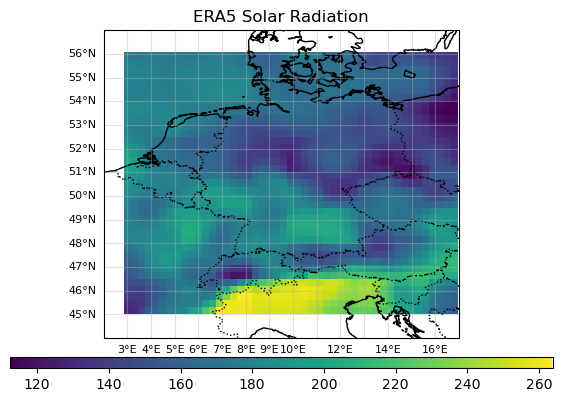

In [ ]:
SSRD_pl = datasets_by_variable['SSRD']

timestep = 90
lon_edges = SSRD_pl['lon'].values
lat_edges = SSRD_pl['lat'].values

fig, ax = plt.subplots(figsize=(10, 5), subplot_kw={'projection': ccrs.PlateCarree()})
ax.set_extent([5-3, 16+1, 47-3, 56+1], crs=ccrs.PlateCarree()) #[5, 16, 47, 56]
ax.coastlines()
ax.add_feature(cfeature.BORDERS, linestyle=':', edgecolor='black')
ax.set_title('ERA5 Solar Radiation')

xxx1 = SSRD_pl['var169'].isel(time=timestep)
im1 = ax.pcolormesh(lon_edges, lat_edges, xxx1, transform=ccrs.PlateCarree(), cmap='viridis')
setup_gridlines(ax)
cbar1 = fig.colorbar(im1, ax=ax, orientation='horizontal', pad=0.05, shrink=0.7, aspect=50)

plt.show()

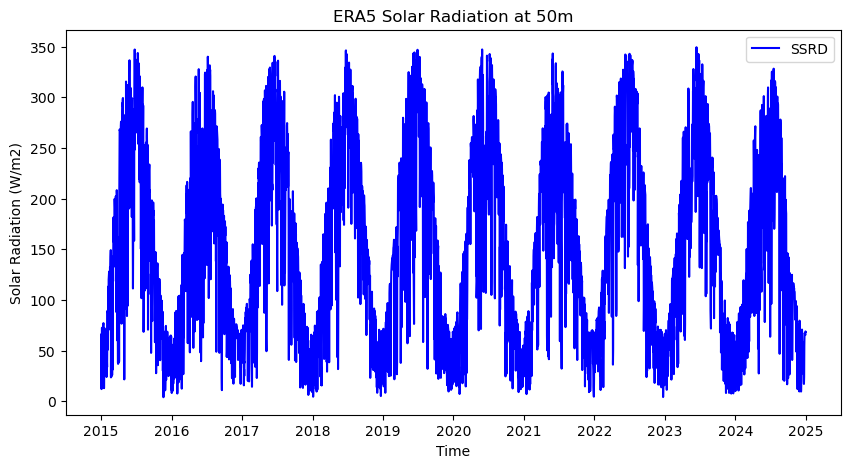

In [12]:
tst = SSRD_pl['var169']
# Plot timeseries of ssrd
fig, ax = plt.subplots(figsize=(10, 5))
tst.isel(lon=10, lat=5).plot(ax=ax, color='blue', label='SSRD')
ax.set_title('ERA5 Solar Radiation at 50m')
ax.set_xlabel('Time')
ax.set_ylabel('Solar Radiation (W/m2)')
ax.legend()
plt.show()

### Prepare data

- rename variables
- regrid data
- calculate windspeed
- convert K to °C
- remove 29.02

In [15]:
var_names = {'var169': 'rsds',
             'var167': 'tas',
             'var246': 'U100',
             'var247': 'V100',
             'tasmax': 'tasmax'}

ds_list = []

for i in datasets_by_variable:
    # print(i)
    # print(datasets_by_variable[i])
    # print('------------------')
    ds = datasets_by_variable[i]
    var = list(ds.data_vars)[0]
    ds = ds.rename({var: var_names[var]})
    ds = ds.sel(lat=slice(45, 60), lon=slice(4, 17))
    nc = grid_func.regrid(ds) # One ° less in the north to prevent NaN values #, s = 47, n = 56, w = 6, e = 16
    # Append to list for later merging
    ds_list.append(nc)
    # ds.to_netcdf(f'/climca/people/onennecke/ERA5/{i}.nc')

# Read in tmax

# Combine all into a single dataset
clim_ds = xr.merge(ds_list)

In [16]:
clim_ds['wind_speed'] = np.sqrt(clim_ds['U100']**2 + clim_ds['V100']**2)
clim_ds['tas'] = clim_ds['tas'] - 273.15
clim_ds['tasmax'] = clim_ds['tasmax'] - 273.15

combined_ds = clim_ds.where(~((clim_ds['time.month'] == 2) & (clim_ds['time.day'] == 29)), drop=True)
combined_ds

<xarray.Dataset> Size: 8MB
Dimensions:     (time: 3650, lat: 9, lon: 10)
Coordinates:
  * time        (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
  * lat         (lat) int64 72B 47 48 49 50 51 52 53 54 55
    crs         int64 8B 4326
    gridtype    <U6 24B 'lonlat'
  * lon         (lon) int64 80B 6 7 8 9 10 11 12 13 14 15
Data variables:
    rsds        (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    U100        (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    V100        (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    tas         (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    tasmax      (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
    wind_speed  (time, lat, lon) float32 1MB dask.array<chunksize=(1, 9, 10), meta=np.ndarray>
Attributes:
    regrid_method:  bilinear